In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
import seaborn as sn
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LinearRegression
import torch

torch.manual_seed(0)
np.random.seed(0)

In [171]:
# As Numpy
train_in  = pd.read_csv("data/train_in.csv",  header=None).values
train_out = pd.read_csv("data/train_out.csv", header=None).values.flatten().astype(int)
test_in   = pd.read_csv("data/test_in.csv",   header=None).values
test_out  = pd.read_csv("data/test_out.csv",  header=None).values.flatten().astype(int)

### Task 1

#### 1.1 head in the clouds

In [172]:
# As DataFrame
train_in_df  = pd.read_csv("data/train_in.csv",  header=None)
train_out_df = pd.read_csv("data/train_out.csv",  header=None)
test_in_df = pd.read_csv("data/test_in.csv",  header=None)
test_out_df = pd.read_csv("data/test_out.csv",  header=None)

In [173]:
train_df = train_in_df.set_index(train_out_df.iloc[:, 0])
centers_df=train_df.groupby(by=train_df.index).mean()

In [174]:
from scipy.spatial.distance import cdist

centers = centers_df.values          # (10, 256) numpy array
dist_matrix = cdist(centers, centers)  # (10, 10) pairwise Euclidean distances

In [175]:
dist_matrix_df = pd.DataFrame(dist_matrix, index=centers_df.index, columns=centers_df.index)

In [176]:
dist_matrix_df.style.background_gradient(cmap='viridis').format('{:.1f}')

0,0,1,2,3,4,5,6,7,8,9
0,,,,,,,,,,
0,0.0,14.4,9.3,9.1,10.8,7.5,8.2,11.9,9.9,11.5
1,14.4,0.0,10.1,11.7,10.2,11.1,10.6,10.7,10.1,9.9
2,9.3,10.1,0.0,8.2,7.9,7.9,7.3,8.9,7.1,8.9
3,9.1,11.7,8.2,0.0,9.1,6.1,9.3,8.9,7.0,8.4
4,10.8,10.2,7.9,9.1,0.0,8.0,8.8,7.6,7.4,6.0
5,7.5,11.1,7.9,6.1,8.0,0.0,6.7,9.2,7.0,8.3
6,8.2,10.6,7.3,9.3,8.8,6.7,0.0,10.9,8.6,10.4
7,11.9,10.7,8.9,8.9,7.6,9.2,10.9,0.0,8.5,5.4
8,9.9,10.1,7.1,7.0,7.4,7.0,8.6,8.5,0.0,6.4


In [177]:
masked = np.where(dist_matrix == 0, np.nan, dist_matrix)
min_val = np.nanmin(masked)
i, j = np.where(masked == min_val)
print(f"Closest pair: digits {i[0]} and {j[0]}, distance = {min_val:.3f}")

Closest pair: digits 7 and 9, distance = 5.426


We expect that there is going to be some misclasification since there are pairs with lower Distances than expected.

### 1.2

In [178]:
pca_result = PCA(n_components=2).fit_transform(train_in)
tsne_result = TSNE(n_components=2, random_state=0).fit_transform(train_in)
umap_result = umap.UMAP(random_state=0).fit_transform(train_in)

c:\Users\aladi\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


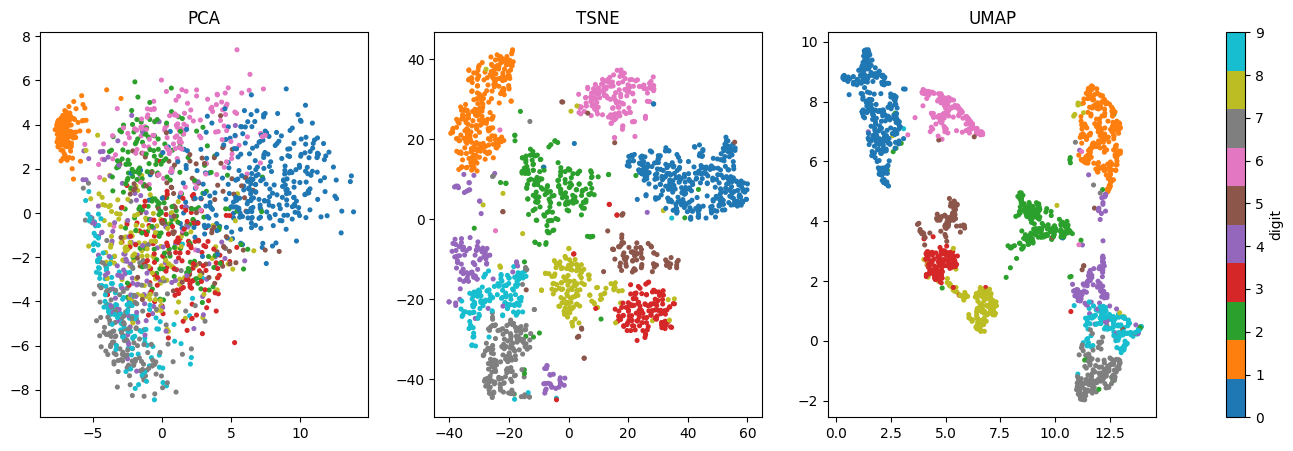

In [179]:
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter0 = axes[0].scatter(pca_result[:,0],pca_result[:,1],s=7,c=train_out, cmap='tab10')
axes[0].set_title('PCA')
scatter1 = axes[1].scatter(tsne_result[:,0],tsne_result[:,1],s=7,c=train_out, cmap='tab10')
axes[1].set_title('TSNE')
scatter2 = axes[2].scatter(umap_result[:,0],umap_result[:,1],s=7,c=train_out, cmap='tab10')
axes[2].set_title('UMAP')
fig.colorbar(scatter0, ax=axes, label='digit')

plt.show()

UMAP shows the most distinct clustering out of all the methods used. TSNE follows with good grouping, only few more overlaps than umap. Lastly PCA shows considerable overlap and not very clear clustering. From all three methods we do observe what was evident from our Euclidian Distance matrix, digits 7 and 9 (dist: 5.4) show overlap and so does 4 and 9 (dist: 6.0).

### 1.3

In [180]:
dist_to_centers_train = cdist(train_in_df, centers_df)   # shape (1707, 10)
dist_to_centers_test  = cdist(test_in_df, centers_df)    # shape (1000, 10)

predictions_train = dist_to_centers_train.argmin(axis=1)   # (1707,) numpy array
predictions_test  = dist_to_centers_test.argmin(axis=1)    # (1000,)

print(f"Train set: Accuracy of Nearest mean classifier predicitons is {(predictions_train == train_out).mean():.2%}")
print(f"Test set: Accuracy of Nearest mean classifier predicitons is {(predictions_test == test_out).mean():.2%}")

Train set: Accuracy of Nearest mean classifier predicitons is 86.35%
Test set: Accuracy of Nearest mean classifier predicitons is 80.40%


### 1.4

In [181]:
#We'll use scikit-learn's KNN
knn = KNeighborsClassifier(n_neighbors=5)# We chose k=5 as a standard default value for KNN; being odd, it also avoids the tie-breaking ambiguity that can occur with even values of k
knn.fit(train_in, train_out)
train_pred_knn = knn.predict(train_in)
test_pred_knn = knn.predict(test_in)
print(f"Train set: Accuracy of KNN predicitons is {(train_pred_knn == train_out).mean():.2%}")
print(f"Test set: Accuracy of KNN predicitons is {(test_pred_knn == test_out).mean():.2%}")

Train set: Accuracy of KNN predicitons is 96.60%
Test set: Accuracy of KNN predicitons is 90.80%


#### Confusion Matrices 

In [182]:
pd.crosstab(test_out,predictions_test, normalize='index').rename_axis(
    index='True digit',columns='Predicted digit'
    ).style.background_gradient(
        cmap='magma_r').format('{:.1%}').set_caption("Nearest Mean Classifier - Confusion Matrix")

Predicted digit,0,1,2,3,4,5,6,7,8,9
True digit,,,,,,,,,,
0,79.5%,0.0%,1.3%,0.9%,1.8%,0.9%,10.3%,0.4%,4.5%,0.4%
1,0.0%,99.2%,0.0%,0.0%,0.0%,0.0%,0.8%,0.0%,0.0%,0.0%
2,2.0%,0.0%,68.3%,5.9%,7.9%,1.0%,0.0%,2.0%,12.9%,0.0%
3,3.8%,0.0%,3.8%,77.2%,1.3%,10.1%,0.0%,0.0%,1.3%,2.5%
4,1.2%,3.5%,3.5%,0.0%,80.2%,0.0%,1.2%,1.2%,0.0%,9.3%
5,5.5%,0.0%,0.0%,10.9%,5.5%,69.1%,1.8%,0.0%,0.0%,7.3%
6,7.8%,0.0%,2.2%,0.0%,2.2%,1.1%,86.7%,0.0%,0.0%,0.0%
7,0.0%,3.1%,1.6%,0.0%,7.8%,0.0%,0.0%,78.1%,0.0%,9.4%
8,3.3%,2.2%,0.0%,6.5%,3.3%,3.3%,0.0%,0.0%,79.3%,2.2%


In [183]:
pd.crosstab(test_out,test_pred_knn, normalize='index').rename_axis(
    index='True digit',columns='Predicted digit'
    ).style.background_gradient(
        cmap='magma_r').format('{:.1%}').set_caption("KNN - Confusion Matrix")

Predicted digit,0,1,2,3,4,5,6,7,8,9
True digit,,,,,,,,,,
0,97.8%,0.0%,0.9%,0.0%,0.4%,0.0%,0.4%,0.0%,0.0%,0.4%
1,0.0%,98.3%,0.0%,0.0%,0.0%,0.0%,1.7%,0.0%,0.0%,0.0%
2,6.9%,2.0%,83.2%,1.0%,0.0%,0.0%,1.0%,3.0%,3.0%,0.0%
3,3.8%,0.0%,2.5%,88.6%,0.0%,2.5%,0.0%,0.0%,0.0%,2.5%
4,0.0%,2.3%,2.3%,0.0%,91.9%,0.0%,0.0%,1.2%,0.0%,2.3%
5,12.7%,1.8%,0.0%,14.5%,1.8%,63.6%,0.0%,0.0%,0.0%,5.5%
6,3.3%,1.1%,0.0%,0.0%,1.1%,0.0%,94.4%,0.0%,0.0%,0.0%
7,0.0%,6.2%,0.0%,1.6%,3.1%,0.0%,0.0%,87.5%,0.0%,1.6%
8,2.2%,2.2%,0.0%,5.4%,0.0%,0.0%,1.1%,1.1%,85.9%,2.2%


- In the case of Nearest Mean Classifier, we observe that some of the important misclassifications with rate >10% were the following: Predicting 3 when digit was 5 (10.9%), predicting 5 when digit was 3 (10.1%), predicting 6 when digit was 0 (10.3%) and predicting 8 when digit was 2 (12.9%).
- In the case of KNN, we observe that some of the important misclassifications with rate >10% were the following: Predicting 0 when digit was 5 (12.7%) and predicting 3 when digit was 5 (14.5%).


We quicly observe that the very high misclasifications happened at digit 5 for both classifiers, while the Nearest mean classifier suffered also in other digits such as 2 (68.3% correctly classified) and 3 (77.2%). Lastly for KNN digit 2 has the second lowest correct classification rate at 83.2%. 

### Task 2

Notes
* We have 10 independent classifiers
* Each classifier has its own weights (256 weights, one for each pixel)
* Putting this in a 10 x 256 matrix 
    * Each row x represents the weights used to recognise digit x
    * We also want to include the bias in the matrix, so it becomes a 10 x 257 matrix

In [184]:
# Set up parameters
n_pixel = 256
n_digit = 10 

# Append column representing bias to the train and test data
X_train = np.column_stack([train_in_df, np.ones(len(train_in_df))])
X_test = np.column_stack([test_in_df, np.ones(len(test_in_df))])

# Implement multi-class perceptron training algorithm
def perceptron_alg(X_set, y_set, epochs = 100, learning_rate = 0.01):

    W = np.random.rand(n_digit, n_pixel + 1) # Initialise random weights

    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)

    for i in range(epochs):
        # Calculate scores
        scores = X_set @ W.T 

        # Make predictions
        predictions = np.argmax(scores, axis = 1)
        train_acc[i] = np.mean(predictions == y_set)

        # Get the wrong predictions
        mask_wrong = (predictions != y_set)
        X_wrong = X_set[mask_wrong]
        y_wrong = y_set[mask_wrong]
        pred_wrong = predictions[mask_wrong]

        # NOTE (see below)
        # Update matrix: +1 for the true class, and -1 for wrong predictions 
        update_matrix = np.zeros((len(X_wrong), n_digit))
        update_matrix[np.arange(len(X_wrong)), y_wrong] = 1 # +1, extra weights for the true class
        update_matrix[np.arange(len(X_wrong)), pred_wrong] = -1 # -1, make dumb pixels (incorrect preds) less relevant

        # 6.7 ?
        dL_dW = update_matrix.T @ X_wrong

        # Update parameters (6.3)
        W += learning_rate * dL_dW

        # Testing 
        test_scores = X_test @ W.T
        test_pred = np.argmax(test_scores, axis = 1)
        test_acc[i] = np.mean(test_pred == y_test)

    return train_acc, test_acc

NOTE: I have no clue if I'm using equation 6.7 (haha funny number) correctly. But the point here is that we decide here to increase the weights for where predictions were done accurately, and decrease weights for wrong predictions. See https://frickp.github.io/matrix-gradient-descent.html for more explanation

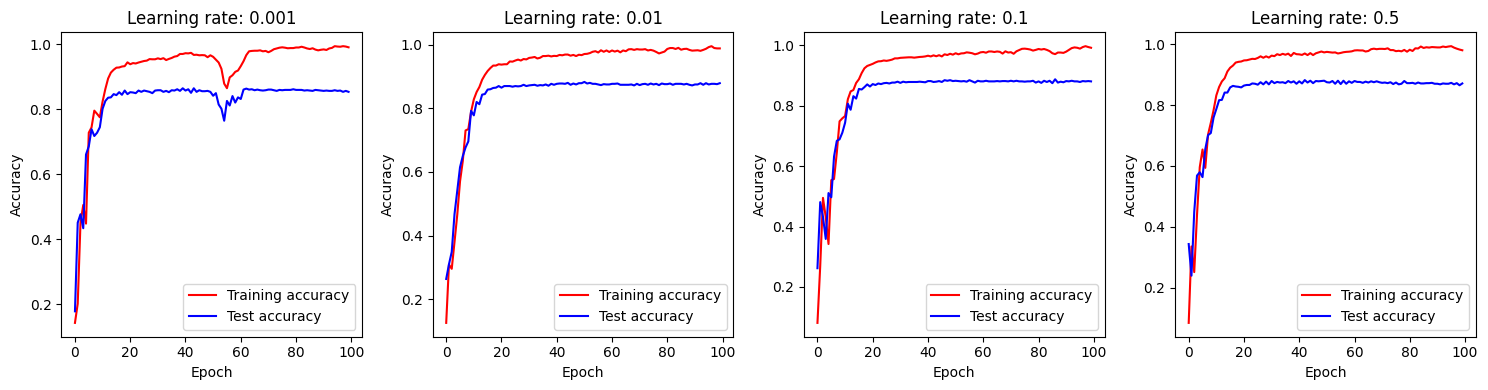

In [185]:
learning_rates = [0.001, 0.01, 0.1, 0.5]

fig, axes = plt.subplots(1, len(learning_rates), figsize = (15, 4))

y_train = np.array(train_out_df).ravel()
y_test = np.array(test_out_df).ravel()

for ax, lr in zip(axes, learning_rates):
    train_acc, test_acc = perceptron_alg(X_train, y_train, learning_rate = lr)

    ax.plot(train_acc, c = "red", label = "Training accuracy")
    ax.plot(test_acc, c = "blue", label = "Test accuracy")
    ax.set_title(f"Learning rate: {lr}")
    ax.set_xlabel("Epoch") # pog
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.tight_layout()
